# Matplotlib - Histograms
___
- EG: `df.plot(kind='hist')`
- Now that we have covered the major Plots such as Line, Scatter and Bar Chart. It's time to move into Statistical Analysis Visualizations.
    - This Section we will cover Histograms
        - Great at showing, the Distribution of Values
        - When looking at Salary, we are able to quickly see that the Salaries group around 100K and when Diverging from that, they become less and less frequent
        - Looking at the Visual we will be building, the Data is scewed to the right, where we have that long tail with the Data going out to 400K, this is pretty common when Analyzing Salary
    - Next Section we will cover Box Plots
- Time to Build that Visual so we can look at it! We start by doing our generic Standard Data Imports and Cleanups of the Job Postings Data

In [1]:
# Imports
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills)else skills)

- Time to Filter the Data down
    - By the specific Job Title - We are Filtering by Data Analyst
    - And by the specific Region - We are Filtering for wherever we are located right now, which would be Canada
    - Also included the `.copy()` Function to make sure the Original DataFrame remains un-altered
- This is because, the Salary will fluctuate depending on where you are around the world and ofc it will fluctuate depending on the Job Title

In [2]:
# Filtering the Data down to Data Analyst and also to only Jobs in Canada
df_DA_CAN = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Canada')].copy()

- Now that we have that done, in order to Generate the Visualization it's pretty simple
    - Provide it: 
        - A Column, and it automatically does the Aggregations necessary to build the Histogram
        - First, using our Created DataFrame of: `df_DA_CAN`
        - Access the `salary_year_avg` Column like so: `df_DA_CAN['salary_year_avg']`
        - Calling the `.plot()` Function
        - Passing in the `kind='hist'`
- Running this: `df_DA_CAN['salary_year_avg'].plot(kind='hist')` will Generate the Histogram correctly!

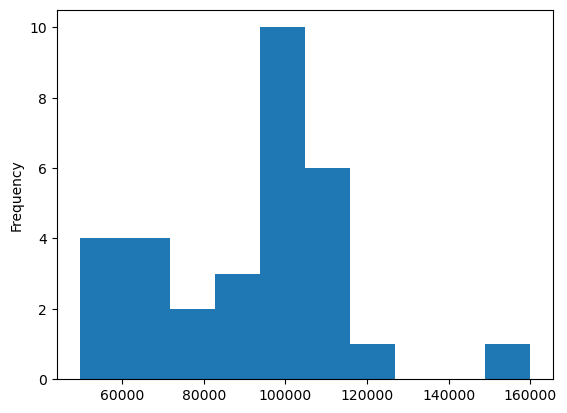

In [4]:
# Generating the Histogram using the salary_year_avg
df_DA_CAN['salary_year_avg'].plot(kind='hist')

plt.show()

- We get back our Histogram... which is a very ugly mess... but nonetheless, it's showing what we need it to
    - But as always, we can fine tune this further!
        - Right now, the Bins (how wide each of the bars are), the 8 Bins we have here are not spread out that much, pretty cramped and really big and hard to read...
        - We can change this by Passing in an Argument into the `.plot()` Function that sets the amount of Bins we want
            - To do this, we can Pass in: `bins=24`

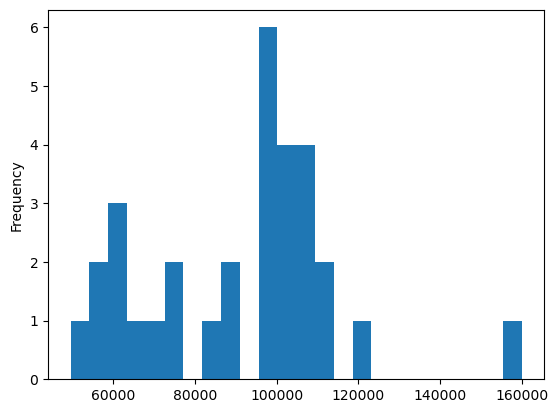

In [5]:
# Increasing the number of Bins on the Histogram
df_DA_CAN['salary_year_avg'].plot(kind='hist', bins=24)

plt.show()

- Passing this Argument in, it makes them a lot smaller and we can see a lot of things within the DataSet
- If we make the Bins, too big of a Number, we are going to start to see a bunch of ups and downs throughout the DataSet and it's not going to tell us as much as we want to
    - So we need to be careful on how big we set our Bins too...

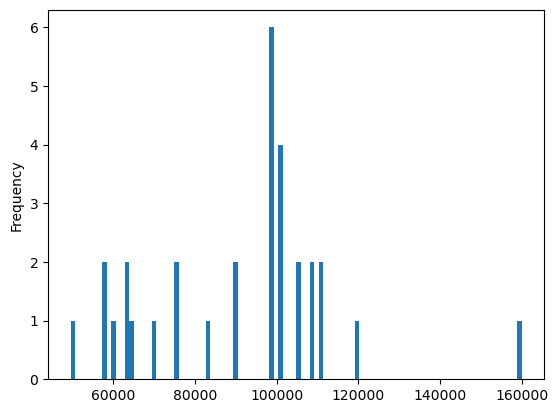

In [6]:
# Increasing the number of Bins on the Histogram and making the number too big, to see how unreadable it becomes
df_DA_CAN['salary_year_avg'].plot(kind='hist', bins=100)

plt.show()

- Because this is too big and not that plesant to look at or even Read... we will stick with the Bins set at 24

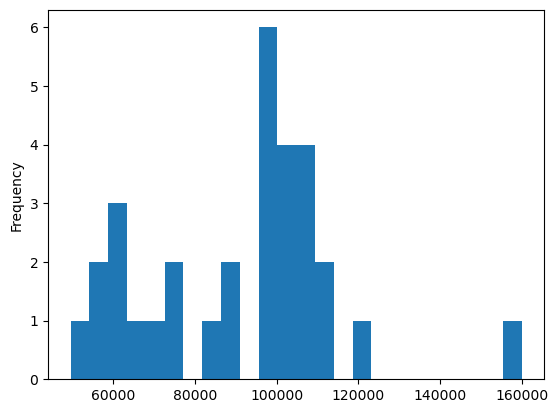

In [7]:
# Keeping the number of Bins to an acceptable and easy to read number
df_DA_CAN['salary_year_avg'].plot(kind='hist', bins=24)

plt.show()

- Last bit of Customization that we can do to this is to Add an Edge around each one of the Bins
    - This will give all the Bins an outline and make it easier to read, while distinguishing the boundaries of each one
    - Makes it easier to see where one ends and the next one begins
    - To do this:
        - Pass in another Argument to the `.plot()` Function
        - This Argument is: `edgecolor=`
        - We set it Equal to the Colour we want the outline to be... in this case we want black, so we add: `'black'`
        - In full it's: `edgecolour='black'`

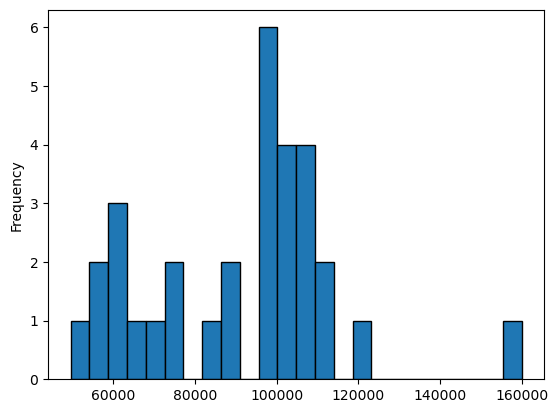

In [8]:
# Adding in an Outline Colour/Edge Line around each of the Bins
df_DA_CAN['salary_year_avg'].plot(kind='hist', bins=24, edgecolor='black')

plt.show()

- Now that we are familiar with how to make **Histograms**
- Let's go through and Clean this up a bit more...
    - The main thing to Focus on is the X Axis... what it's Displaying is not really clear
    - What is actually being shown is the Salaries, but it's not really known from a glance, it's a bit muddled so it's time to fix that
    - AS well as this, we also have a pretty long tail on this... with the outlier. There's not really a lot of Value here after 120_000 since there's only 1 Bin there
    - Because it's not really telling us anything, we don't really need it in there
    - To get rid of all this:
        - Start by Calling `plt.xlim()`
            - We will need to Pass in 2 Arguments or rather Values inside here
                - Provide the Start which would usually be 0 - In our case, there's no Values between 0 and 45_000 so it's a lot of empty space. I'm starting at 45_000
                - Provide the End which is where we want to go. This Value would be 125_000

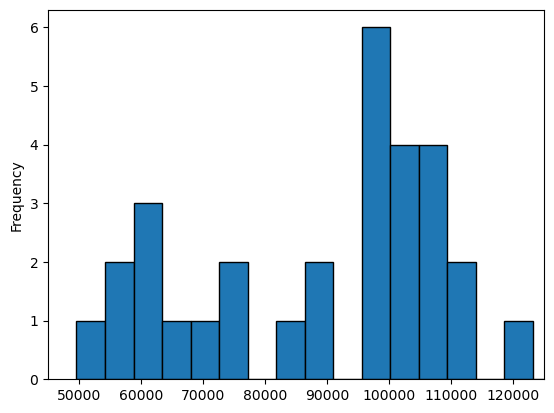

In [13]:
# Cleaning up the X Axis by putting in a Start and end Value to remove the outliers
df_DA_CAN['salary_year_avg'].plot(kind='hist', bins=24, edgecolor='black')

plt.xlim(45_000, 125_000)
plt.show()

- Running this, we can now see a lot closer into the Histogram
- If we wanted to, because we are now more zoomed in, we could boost up the Bin Number a little bit...

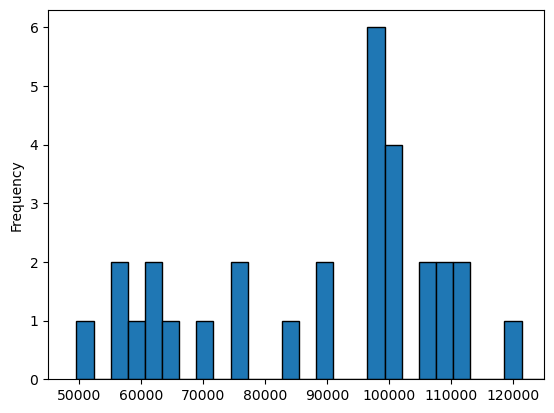

In [15]:
# Increasing the Bin Number
df_DA_CAN['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')

plt.xlim(45_000, 125_000)
plt.show()

- Last thing to do is Format the X Axis...
- In the last lesson, we went through and Formatted these Number Values to have a Dollar Sign at the Front, a K at the end, and then Cut it off on the Thousands Place
- Grabbing that Code that we worked on Last Lesson, and Pasting it in here to Update our X Axis

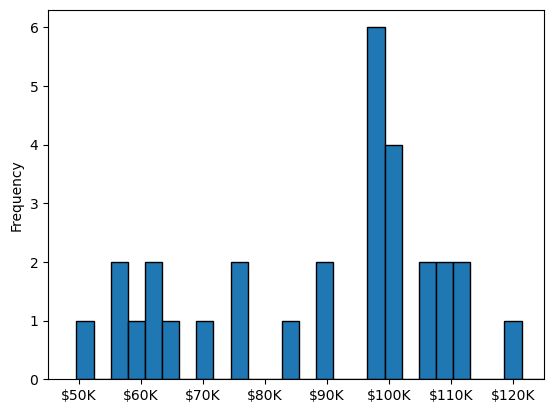

In [ ]:
# Cleaning up the X Axis and Formatting the Values Properly on there
df_DA_CAN['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.xlim(45_000, 125_000)
plt.show()

- Now we have Number Values!! And these are encased by having a **$** at the Front and have the **K** at the end and cutting the Number off at the Thousanth Place
- And like usual, the last thing to do for Cleanup is to Add Titles, to the Visual itself, along with the X and Y Axis

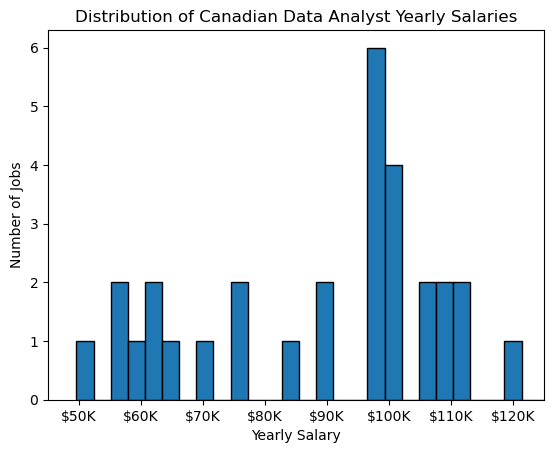

In [19]:
# Adding the Final Clean up by Adding Titles to the Visual, X and Y Axis
df_DA_CAN['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.xlim(45_000, 125_000)
plt.title('Distribution of Canadian Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.show()

### Closing Remarks and Insights Learned
___
- We now have this absolutely beautiful Visualization!
- This now shows the Distribution of our different Salaries
    - Looking at it, we can really see the Median is somewhere around 55K to 65K for these Yearly Salaries - which would be around 80K to 90K USD
    - Along with Showcasing how it has a good Distribution of Salaries and no tail exists anymore
- A lot of great Insights coming out of this!